# Introducción

En la presente demo usaremos el algoritmo de K-means para agrupar clientes en dos clústeres. La idea es usar el conjunto de datos que limpiamos y analizamos en el notebook anterior (ver notebook CreditRiskAnalysis.ipynb en el presente repositorio). Lo que queremos hacer es quitar la variable Risk que indica si un cliente tiene alto o bajo riesgo de no pagar un crédito y ver si el algoritmo de K-means logra segmentar a los clientes en dos clústeres uno de alto riesgo y otro de bajo riesgo.

Dado que K-means es un algoritmo no supervisado este segmentará a los clientes dependiendo de las características naturales de la información, es decir, el algoritmo no necesariamente va a discriminar entre clientes "Good" y clientes "Bad", sin embargo, al final de esta demo aplicaremos un "truco" para hacer que el algoritmo no supervisado intente segmentar a los clientes por la variable "Risk" sin que el algoritmo llegue a conocerla.

Antes de comenzar importemos las librerías necesarias:

In [10]:
# Importación de las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap
import warnings

#Módulos de Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve
)

# K-means
Como ya comentamos, los datos se encuentran limpios y listos para su uso ya que en el notebook CreditRiskAnalysis.ipynb hicimos toda la preparación y limpieza de los mismos. Entonces podemos pasar directamente a la ingesta de los datos hacia el modelo y  al entrenamiento:

In [38]:
# Importación de los datos
df = pd.read_csv("dataset/german_data.csv")

# Selección de features
X = df.drop(columns=["Risk","Personal status and sex"])

# Identificación de features numéricas
features_numericas = X.select_dtypes(include=["int64"]).columns

# Identificación de features categóricas
features_categoricas = X.select_dtypes(include=["str"]).columns

# Definimos una transformación para el preprocesamiento
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_categoricas)
    ]
)

# Definimos el modelo en un pipeline
model = Pipeline(
    steps=[("preprocesamiento", preprocesamiento),
        ("clustering", KMeans(n_clusters=2, random_state=42, n_init="auto"))
    ]
)

# Entrenamiento del modelo
model.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('clustering', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Status of existing checking account','Duration in month', 'Credit history',...,'Foreign worker','Sex','Personal status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` 

Ahora que nuestro modelo ha sido entrenado podemos usarlo para predecir en que clúster está cada cada cliente. Hacerlo es inmediato con el siguiente comando:

In [39]:
df["Cluster"] = model.fit_predict(X)
df[["Credit history","Cluster"]].head()

,Credit history,Cluster
0,critical account/other credits existing (not a...,1
1,existing credits paid back duly till now,0
2,critical account/other credits existing (not a...,1
3,existing credits paid back duly till now,1
4,delay in paying off in the past,1


La pregunta del millón, el valor de "Cluster" coincidrá con con el valor de la variable "Risk". Podemos averiguarlo agrupando por Cluster y contanto cuantas veces aparece "Good" o "Bad" en cada segmento:

In [40]:
df.groupby(["Cluster","Risk"])["Risk"].count()

Cluster  Risk
0        Bad     109
         Good    201
1        Bad     191
         Good    499
Name: Risk, dtype: int64

Como podemos notar el algoritmo de K-means esta agrupado a los clientes, en el clúster 0 hay 109 clientes "Bad" y 201 clientes "Good" y en clúster 1 hasta 191 clientes "Bad" y 499 "Good". Si suponemos que el clúster 0 representa a los clientes "Bad" y el clúster 1 a los clientes "Good" entonces podemos obtener la siguiente matriz de confusión:

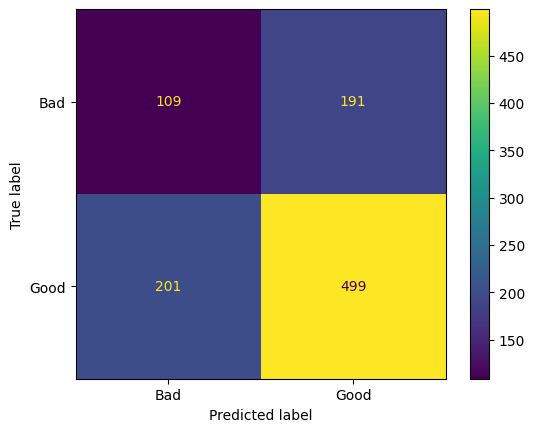

In [41]:
df["Risk_predicted"] = df["Cluster"].map({0:"Bad", 1:"Good"})
ConfusionMatrixDisplay.from_predictions(df["Risk"], df["Risk_predicted"])
plt.show()

Y las métricas son las siguientes:

In [42]:
print("Accuracy :", accuracy_score(df["Risk"], df["Risk_predicted"]))
print("Precision:", precision_score(df["Risk"], df["Risk_predicted"], pos_label="Bad" ))
print("Recall   :", recall_score(df["Risk"], df["Risk_predicted"], pos_label="Bad"))
print("F1       :", f1_score(df["Risk"], df["Risk_predicted"], pos_label="Bad"))

Accuracy : 0.608
Precision: 0.35161290322580646
Recall   : 0.36333333333333334
F1       : 0.35737704918032787


El mejor modelo de regresión logística que entrenamos en un notebook previo dio los siguientes resultados:

Como podemos notar, nuestro algoritmo no supervisado está muy lejos de ser comparable con una regresión logística. Esto era de esperarse, ya que K-means no conoce en ningún momento la variable "Risk" y solo intenta segmentar a los clientes en base a las "distancias" que existen entre los datos. Para intenar dilucidar que realmente representa el clúter 0 y el clúster 1 podemos hacer una análisis más profundo, por ejemplo, agrupar las variables numéricas por cluster y ver como cambia el promedio en cada clúster:

In [49]:
resultado = df.groupby("Cluster")[features_numericas].mean().transpose()
resultado["Diferencia absoluta (%)"] = abs(resultado[0]-resultado[1])/resultado[0]*100
resultado

Cluster,0,1,Diferencia absoluta (%)
Duration in month,19.438710,21.560870,10.917185
Credit amount,2877.774194,3448.040580,19.816231
Installment rate in percentage of disposable income,2.829032,3.037681,7.375275
Present residence since,2.867742,2.834783,1.149313
Age in years,32.803226,36.778261,12.117818
Number of existing credits at this bank,1.325806,1.443478,8.875489
Number of people being liable to provide maintenance for,1.045161,1.204348,15.230811


Como podemo notar, no parece haber mucha diferencia absoluta porcentual entre los promedios del clúster 0 vs los promedios del clúster 1. La mayor diferencia se observa en "Credit amount" con casi el 20%. Para seguir indagando que representa cada clúster veamos como se comparan las variables categóricas entre clústeres:

In [114]:
features_categoricas[13]

'Personal status'

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (3,).

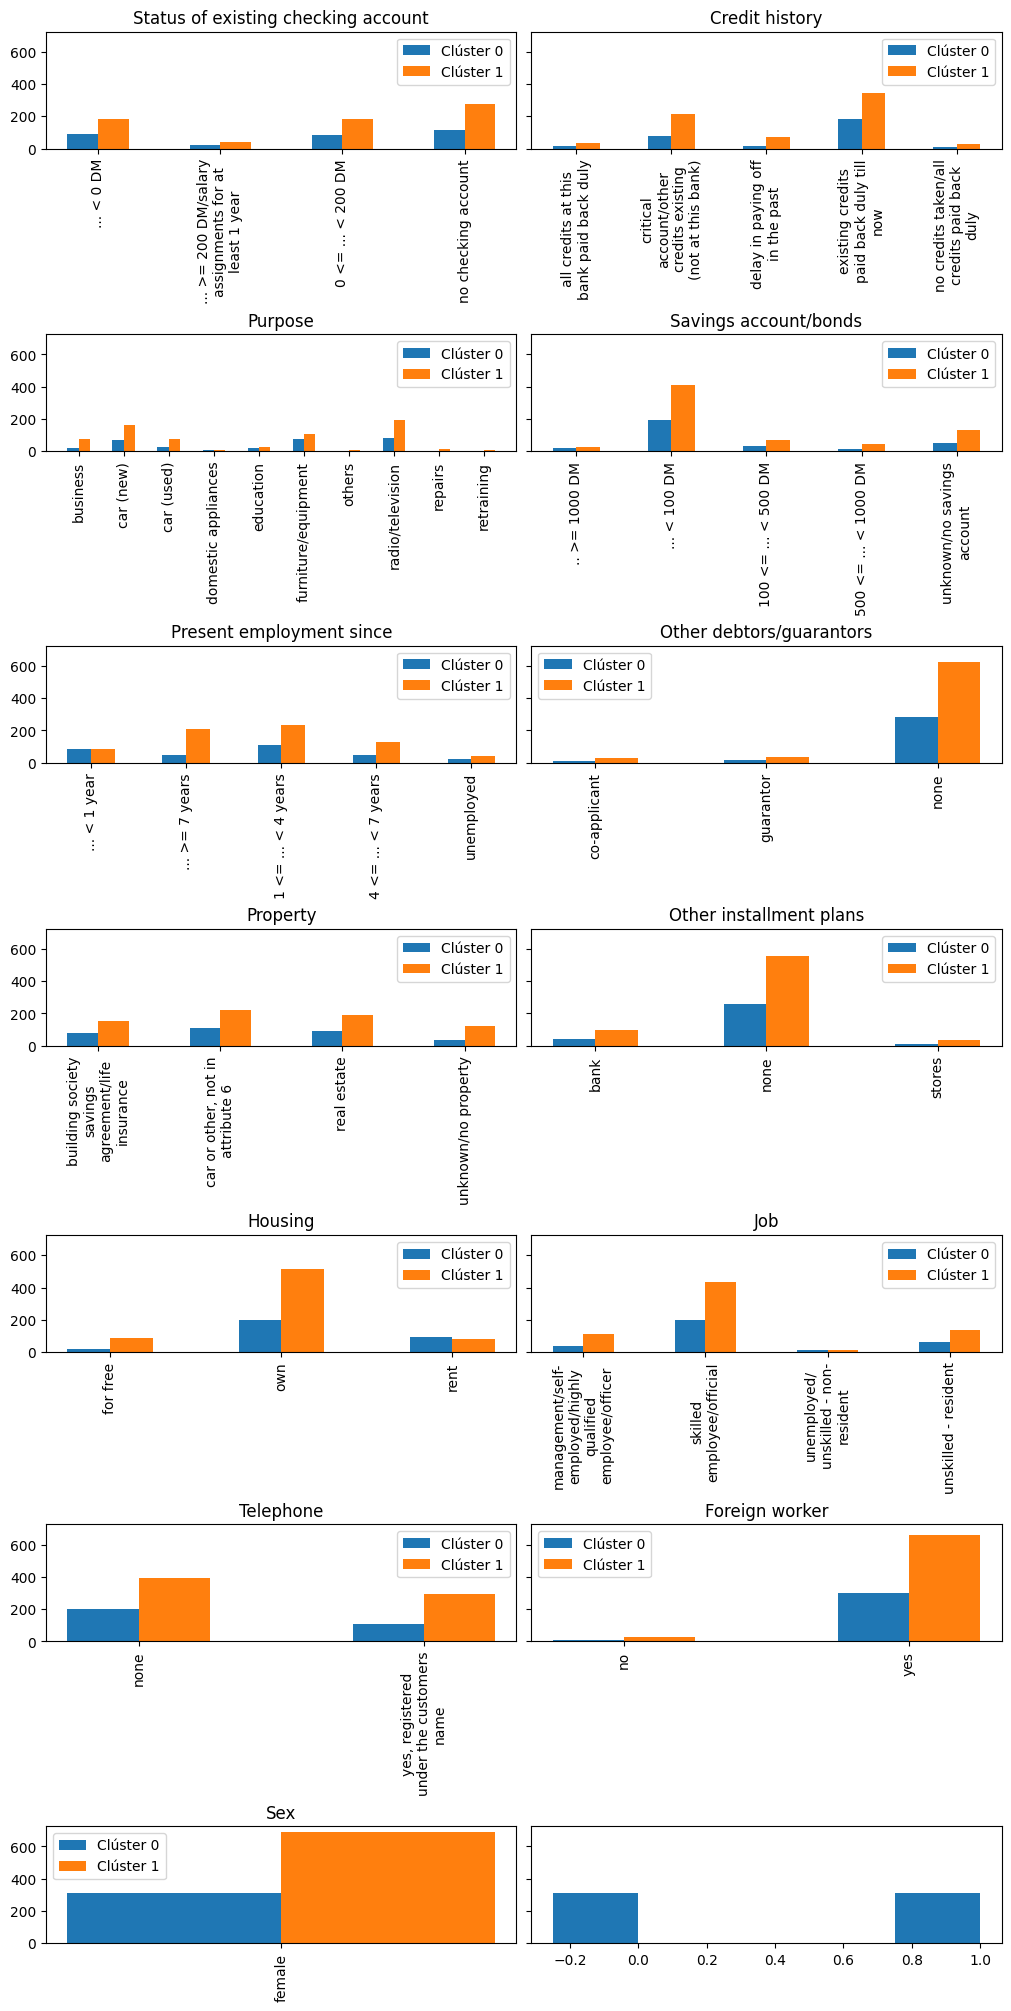

In [113]:
fig, axes = plt.subplots(7, 2,figsize=(10, 20), sharey=True, constrained_layout=True)
axes = axes.flatten()

ancho = 0.25
longitudEtiquetas = 20
for i in range(0,14):
    nombre_feature = features_categoricas[i]
    resultado = df.groupby(["Cluster", nombre_feature])[nombre_feature].count()\
        .to_frame().rename(columns={nombre_feature:"count"}).reset_index()
    resultado[nombre_feature] = resultado[nombre_feature]\
        .apply(lambda x: textwrap.fill(str(x), width=longitudEtiquetas))

    x = np.arange(len(resultado)/2)
    axes[i].bar(x-ancho*0.5, resultado[resultado["Cluster"]==0]["count"], width=ancho, label='Clúster 0')
    axes[i].bar(x+ancho*0.5, resultado[resultado["Cluster"]==1]["count"], width=ancho, label='Clúster 1')
    axes[i].set_xticks(x, resultado[resultado["Cluster"]==0][nombre_feature], rotation=90)
    axes[i].legend(loc='best')
    axes[i].set_title(nombre_feature)
    if i==13:
        break
plt.show()

In [115]:
df.groupby(["Cluster", "Personal status"])["Personal status"].count()\
        .to_frame().rename(columns={"Personal status":"count"}).reset_index()

,Cluster,Personal status,count
0,0,divorced/separated/married,310
1,1,divorced/separated,50
2,1,married/widowed,92
3,1,single,548


In [116]:
df.groupby(["Cluster", "Sex"])["Sex"].count()\
        .to_frame().rename(columns={"Sex":"count"}).reset_index()

,Cluster,Sex,count
0,0,female,310
1,1,male,690
